# Model Training

This notebook focuses on training and evaluating the baseline Logistic Regression model using the preprocessed application data.

The preprocessing steps were completed in '02_model_development.ipynb'. The saved training and validation datasets are loaded here to avoid repeating preprocessing.

## 6. Baseline Logistic Regression

The baseline model is trained to establish an initial performance benchmark. Its results will be used to evaluate whether later modeling approaches and feature engineering provide meaningful improvements.

### 6.1 Model Training

In [1]:
# import libraries
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

from optbinning import BinningProcess

import matplotlib.pyplot as plt

In [2]:
# import datasets
X_train_model = joblib.load('model_data/X_train_model.joblib')
X_valid_model = joblib.load('model_data/X_valid_model.joblib')

X_train_scaled = joblib.load('model_data/X_train_scaled.joblib')
X_valid_scaled = joblib.load('model_data/X_valid_scaled.joblib')

y_train = joblib.load('model_data/y_train.joblib')
y_valid = joblib.load('model_data/y_valid.joblib')

In [3]:
baseline_lr = LogisticRegression(max_iter = 1000)

baseline_lr.fit(X_train_scaled, y_train)

/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 6.2.Probability Predictions

In [4]:
y_train_predict = baseline_lr.predict(X_train_scaled)
y_valid_predict = baseline_lr.predict(X_valid_scaled)

/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [5]:
y_train_proba = baseline_lr.predict_proba(X_train_scaled)[:, 1]
y_valid_proba = baseline_lr.predict_proba(X_valid_scaled)[:, 1]

/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


### 6.3 Discrimination Performance

In [6]:
train_auc = roc_auc_score(y_train, y_train_proba)
valid_auc = roc_auc_score(y_valid, y_valid_proba)

train_gini = 2*train_auc - 1
valid_gini = 2*valid_auc - 1

print('Train ROC-AUC:', train_auc)
print('Train GINI:', train_gini)
print('\n')
print('Validation ROC-AUC:', valid_auc)
print('Validation GINI:', valid_gini)

Train ROC-AUC: 0.7511534708949521
Train GINI: 0.5023069417899042


Validation ROC-AUC: 0.7505652161971323
Validation GINI: 0.5011304323942647


The baseline Logistic Regression achieved a ROC-AUC of 0.7512 on the training set and 0.7506 on the validation set. The corresponding Gini coefficients were 0.5023 and 0.5011.

The small train-validation gap indicates that discrimination performance is consistent across the two samples. However, this does not establish temporal stability or probability calibration, which will be assessed separately.

### 6.4 Precision-Recall Performance

In [7]:
train_ap = average_precision_score(y_train, y_train_proba)
valid_ap = average_precision_score(y_valid, y_valid_proba)

print('Train Average Precision:', train_ap)
print('Valid Average Precision:', valid_ap)


Train Average Precision: 0.22902851663785637
Valid Average Precision: 0.23557863810134075


The baseline model achieved an Average Precision of 0.2290 on the training set and 0.2356 on the validation set.

Both values are above the positive class prevalence of approximately 8.07%, indicating that the model provides useful ranking information for identifying clients with repayment difficulties. The small difference between training and validation performance does not indicate substantial deterioration on this split.

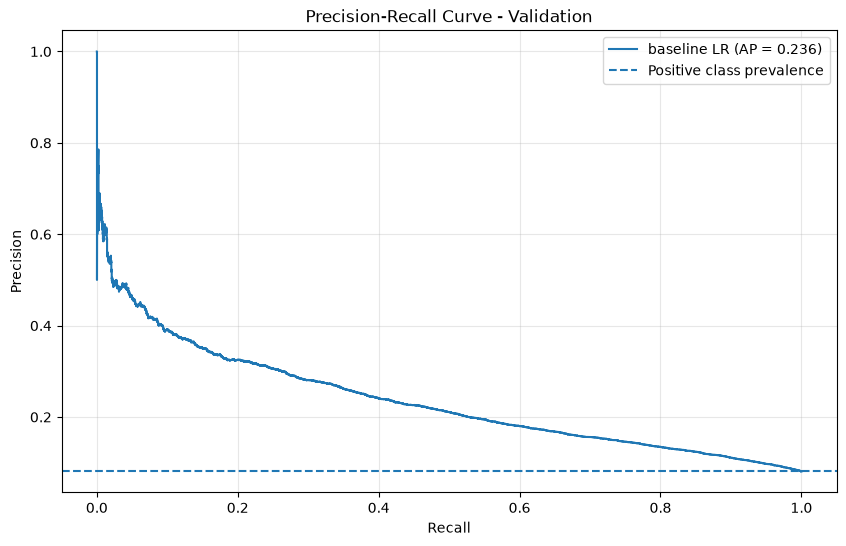

In [8]:
precision, recall, thresholds = precision_recall_curve(
    y_valid, y_valid_proba
)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(recall, precision, label=f'baseline LR (AP = {valid_ap:.3f})')
plt.axhline(y_valid.mean(), linestyle = '--', label = 'Positive class prevalence')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation')
plt.legend()
plt.grid(alpha = 0.3)

plt.show()

The Precision-Recall curve shows that precision decreases as recall increases. The model achieves higher precision when focusing on a smaller group of clients with the highest predicted risk, while identifying a larger proportion of positive cases requires accepting more false positives.

The curve remains above the positive class prevalence baseline, supporting the model's ability to rank clients with repayment difficulties. The appropriate classification threshold will depend on the business objective and the relative costs of false positives and false negatives.

### 6.5 Classification Performance

In [9]:
threshold = 0.5

y_valid_pred = (y_valid_proba >= threshold).astype(int)

In [10]:
cm = confusion_matrix(y_valid, y_valid_pred)
print(cm)

[[56499    39]
 [ 4906    59]]


In [11]:
print('Recall:', recall_score(y_valid, y_valid_pred))
print('Precision:', precision_score(y_valid, y_valid_pred))
print('F1_score:', f1_score(y_valid, y_valid_pred))

Recall: 0.011883182275931522
Precision: 0.6020408163265306
F1_score: 0.023306340114556588


In [12]:
print('Observed rate:', y_valid.mean())
print('Average predicted probability:', y_valid_proba.mean())

Observed rate: 0.08072776937710356
Average predicted probability: 0.08048154258389427


The observed positive class rate is 8.073%, while the average predicted probability is 8.048%. The small difference indicates no substantial aggregate underestimation or overestimation of risk.

However, aggregate agreement does not guarantee calibration across different risk levels. The low recall at a threshold of 0.5 reflects the classification decision rule and should be considered separately from probability calibration.

In [13]:
thresholds = np.linspace(0.1, 0.5, 9)
results = []

for threshold in thresholds:
    y_pred = (y_valid_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
    results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_valid, y_pred),
        'Recall': recall_score(y_valid, y_pred),
        'F1 score': f1_score(y_valid, y_pred)
        })
    
threshold_results = pd.DataFrame(results)
threshold_results

,Threshold,Precision,Recall,F1 score
0,0.10,0.181987,0.592548,0.278453
1,0.15,0.239200,0.407049,0.301327
2,0.20,0.291013,0.276536,0.283590
3,0.25,0.330477,0.178651,0.231926
4,0.30,0.377483,0.114804,0.176062
5,0.35,0.425000,0.071903,0.122997
6,0.40,0.481651,0.042296,0.077763
7,0.45,0.497797,0.022759,0.043529
8,0.50,0.602041,0.011883,0.023306


The threshold analysis shows a clear trade-off between Precision and Recall. At a threshold of 0.10, the model detects 59.25% of clients with repayment difficulties, with a Precision of 18.20%. At 0.15, Recall decreases to 40.70%, while Precision improves to 23.92%.

If the business prioritizes detecting clients with repayment difficulties, thresholds of 0.10 and 0.15 are reasonable candidates for further evaluation. However, a lower threshold also increases false positives, which may lead to unnecessary reviews or the rejection of potentially profitable clients.

The final threshold should therefore depend on the model's intended use, the costs of false positives and false negatives, and business constraints. No operational threshold is selected at this stage.

### 6.6 Baseline Conclusion

The baseline Logistic Regression achieved a validation ROC-AUC of 0.7506, Gini of 0.5011, and Average Precision of 0.2356. The small train-validation performance gap suggests that discrimination is relatively consistent across the two samples.

The model shows useful ranking ability, but classification performance depends strongly on the selected threshold. Lower thresholds improve Recall at the cost of more false positives. The average predicted probability is also close to the observed positive class rate, although calibration across risk levels has not yet been assessed.

This baseline will be used as a benchmark for further feature analysis and model development. No final operational threshold has been selected.

## 7. WOE and Information Value
WOE analysis is used to examine how the distribution of positive and negative clients differs across feature groups. The binning rules and WOE values will be learned from the training data only and then applied to validation data.

### 7.1 WOE — Weight of Evidence

In [14]:
data_woe = pd.read_csv('data/preprocessed_data.csv')

X_train_woe_raw = data_woe.loc[y_train.index].drop(
    columns = ['SK_ID_CURR', 'TARGET']
)

X_valid_woe_raw = data_woe.loc[y_valid.index].drop(
    columns=['SK_ID_CURR', 'TARGET']
)

print(X_train_woe_raw.shape)
print(X_valid_woe_raw.shape)

(246008, 126)
(61503, 126)


In [15]:
categorical_woe_cols = X_train_woe_raw.select_dtypes(include=['object', 'category']).columns.to_list()

numeric_woe_cols = X_train_woe_raw.select_dtypes(include = 'number').columns.to_list()

/var/folders/yr/jpmjpd_j7s59ts2plwx42_vw0000gn/T/ipykernel_2920/677658763.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_woe_cols = X_train_woe_raw.select_dtypes(include=['object', 'category']).columns.to_list()


### 7.2 WoE Binning Process

The binning process is fitted only on the training data to avoid target leakage.

Numerical and categorical variables are automatically divided into bins based on their relationship with the target. These bins will later be used to calculate Information Value and transform the original features into WoE values.

In [16]:
assert X_train_woe_raw.index.equals(y_train.index)
assert X_valid_woe_raw.index.equals(y_valid.index)

assert np.array_equal(
    data_woe.loc[y_train.index, 'TARGET'].to_numpy(),
    y_train.to_numpy()
)

assert np.array_equal(
    data_woe.loc[y_valid.index, 'TARGET'].to_numpy(),
    y_valid.to_numpy()
)

print('Train and Validation alignment: OK')

Train and Validation alignment: OK


In [17]:
variable_names = X_train_woe_raw.columns.tolist()

binning_process = BinningProcess(
    variable_names = variable_names,
    categorical_variables = categorical_woe_cols,
    max_n_prebins = 10,
    max_n_bins = 5,
    min_bin_size = 0.05,
    n_jobs = 1
)

In [18]:
binning_process.fit(X_train_woe_raw, y_train)

/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/tural/Desktop/VS Code/Home Credit Risk/.venv/lib/

,variable_names,"['NAME_CONTRACT_TYPE', 'CODE_GENDER', ...]"
,max_n_prebins,10
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,5
,min_bin_size,0.05
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,None
,fixed_variables,None


### 7.3 Information Value Analysis

Information Value (IV) is used to measure the predictive strength of each variable with respect to the target.

The IV values are obtained from the binning process fitted on the training data. Variables are ranked by IV to identify the strongest and weakest individual predictors.

IV is used here as a diagnostic measure rather than as an automatic feature selection rule.

In [19]:
iv_summary = binning_process.summary()

display(iv_summary.head())

print(iv_summary['status'].value_counts())

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,NAME_CONTRACT_TYPE,categorical,OPTIMAL,True,2,0.014871,0.001847,0.033135,0.014236
1,CODE_GENDER,categorical,OPTIMAL,True,2,0.038423,0.004793,0.095042,0.095602
2,FLAG_OWN_CAR,categorical,OPTIMAL,True,2,0.006104,0.000763,0.036564,0.015212
3,FLAG_OWN_REALTY,categorical,OPTIMAL,True,2,0.000452,0.000057,0.00984,0.001064
4,CNT_CHILDREN,numerical,OPTIMAL,True,3,0.006222,0.000777,0.036892,0.005617


status
OPTIMAL    126
Name: count, dtype: int64


In [20]:
iv_summary = iv_summary.sort_values(
    by = 'iv',
    ascending = False
)

iv_summary.head(10)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
41,EXT_SOURCE_3,numerical,OPTIMAL,True,5,0.325606,0.03938,0.305968,0.908941
40,EXT_SOURCE_2,numerical,OPTIMAL,True,5,0.304956,0.036833,0.294336,0.830016
39,EXT_SOURCE_1,numerical,OPTIMAL,True,5,0.147214,0.017882,0.177451,0.42976
16,DAYS_EMPLOYED,numerical,OPTIMAL,True,5,0.113293,0.014044,0.182966,0.410849
26,OCCUPATION_TYPE,categorical,OPTIMAL,True,5,0.09142,0.011358,0.166504,0.330018
15,DAYS_BIRTH,numerical,OPTIMAL,True,5,0.087233,0.010815,0.16136,0.308032
8,AMT_GOODS_PRICE,numerical,OPTIMAL,True,5,0.08389,0.01038,0.14951,0.301852
38,ORGANIZATION_TYPE,categorical,OPTIMAL,True,5,0.072062,0.008954,0.145639,0.259363
10,NAME_INCOME_TYPE,categorical,OPTIMAL,True,4,0.056018,0.006966,0.119519,0.175064
6,AMT_CREDIT,numerical,OPTIMAL,True,5,0.054549,0.006769,0.122519,0.189339


In [21]:
iv_summary['iv'] = pd.to_numeric(iv_summary['iv'])

iv_summary.describe()

,iv
count,126.000000
mean,0.025707
std,0.043497
min,0.000000
25%,0.005121
50%,0.016387
75%,0.031259
max,0.325606


In [22]:
iv_summary[iv_summary['iv'] < 0.02][['name', 'iv']].sort_values('iv')

,name,iv
103,FLAG_DOCUMENT_11,0.000000
121,EXT_SOURCE_2_MISSING,0.000000
111,FLAG_DOCUMENT_19,0.000000
20,FLAG_MOBIL,0.000000
124,SOCIAL_CIRCLE_MISSING,0.000000
...,...,...
52,LIVINGAPARTMENTS_AVG,0.016924
64,FLOORSMIN_MODE,0.017088
50,FLOORSMIN_AVG,0.017527
78,FLOORSMIN_MEDI,0.017594


In [24]:
# Check the number of columns by IV
print('IV < 0.02:', (iv_summary['iv'] < 0.02).sum())
print('0.02 <= IV < 0.10:', ((iv_summary['iv'] >= 0.02) & (iv_summary['iv'] < 0.1)).sum())
print('0.10 <= IV < 0.3:', ((iv_summary['iv'] >= 0.1) & ((iv_summary['iv']) < 0.3)).sum())
print('0.3 <= IV < 0.50:', ((iv_summary['iv'] >= 0.3) & (iv_summary['iv'] < 0.5)).sum())
print('IV >= 0.5:', ((iv_summary['iv'] >= 0.5)).sum())

IV < 0.02: 72
0.02 <= IV < 0.10: 50
0.10 <= IV < 0.3: 2
0.3 <= IV < 0.50: 2
IV >= 0.5: 0


All 126 variables were successfully binned. Most variables show weak individual predictive power, while 'EXT_SOURCE_2' and 'EXT_SOURCE_3' have the strongest IV values.

Low-IV variables are not removed automatically at this stage, because IV reflects individual predictive strength and does not capture the combined contribution of variables in the model.

### 7.4 WOE Transformation

The binning rules learned from the training data are used to transform both training and validation features into WoE values.

The validation data is transformed using the same binning rules without refitting, which prevents target leakage.

In [25]:
X_train_woe = binning_process.transform(
    X_train_woe_raw,
    metric = 'woe'
)

X_valid_woe = binning_process.transform(
    X_valid_woe_raw,
    metric = 'woe'
)

In [26]:
X_valid_woe

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_1_MISSING,EXT_SOURCE_2_MISSING,EXT_SOURCE_3_MISSING,CREDIT_BUREAU_REQ_MISSING,SOCIAL_CIRCLE_MISSING,DAYS_EMPLOYED_SPECIAL
256571,-0.036076,-0.250239,0.112807,0.014267,-0.120701,-0.061658,0.148331,-0.366634,0.378784,0.097132,...,0.048688,0.039497,0.218799,0.005952,-0.059399,0.0,0.040874,0.048688,0.0,-0.077140
191493,-0.036076,0.154039,-0.054141,-0.031715,0.053457,-0.061658,-0.241305,-0.102981,-0.277786,0.097132,...,0.048688,0.096654,0.029586,-0.083715,0.081297,0.0,0.040874,0.048688,0.0,-0.077140
103497,-0.036076,-0.250239,-0.054141,0.014267,0.053457,-0.061658,-0.241305,-0.102981,0.018858,-0.015769,...,0.048688,0.039497,0.029586,0.005952,-0.059399,0.0,0.040874,0.048688,0.0,-0.077140
130646,-0.036076,0.154039,-0.054141,-0.031715,0.053457,0.042962,0.148331,-0.021636,0.378784,-0.015769,...,0.048688,0.039497,0.029586,0.100257,0.081297,0.0,0.040874,0.048688,0.0,-0.077140
211898,-0.036076,0.154039,-0.054141,0.014267,0.053457,-0.061658,-0.241305,-0.102981,0.018858,-0.015769,...,0.048688,0.039497,0.029586,0.100257,-0.059399,0.0,0.040874,0.048688,0.0,-0.077140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16213,-0.036076,0.154039,-0.054141,0.014267,0.053457,-0.061658,0.148331,-0.102981,0.378784,-0.015769,...,0.048688,0.039497,0.029586,0.130375,-0.059399,0.0,0.040874,0.048688,0.0,0.436878
294620,-0.036076,-0.250239,0.112807,0.014267,0.053457,-0.061658,0.148331,-0.021636,0.378784,0.097132,...,0.048688,0.096654,0.218799,0.100257,0.081297,0.0,0.040874,0.048688,0.0,-0.077140
234384,-0.036076,0.154039,0.112807,0.014267,-0.120701,0.344875,0.041078,-0.102981,0.018858,-0.015769,...,0.048688,0.039497,0.029586,0.100257,0.081297,0.0,0.040874,0.048688,0.0,-0.077140
149027,-0.036076,-0.250239,0.112807,0.014267,0.053457,0.344875,0.148331,0.323489,0.378784,-0.015769,...,0.048688,0.039497,0.029586,0.005952,0.081297,0.0,0.040874,0.048688,0.0,-0.077140


In [30]:
# Check for missing and inf values
print('Train NaN:', X_train_woe.isna().sum().sum())
print('Validation NaN:', X_valid_woe.isna().sum().sum())

print('Train inf:', np.isinf(X_train_woe).sum().sum())
print('Validation inf:', np.isinf(X_valid_woe).sum().sum())


Train NaN: 0
Validation NaN: 0
Train inf: 0
Validation inf: 0


## 8. Logistic Regression with WoE Features

A second Logistic Regression model is trained using the WoE-transformed features.

This allows us to evaluate whether supervised binning and WoE transformation improve model discrimination compared with the baseline model.

In [32]:
woe_lr = LogisticRegression(max_iter = 1000)

woe_lr.fit(X_train_woe, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
y_train_woe_proba = woe_lr.predict_proba(X_train_woe)[:, 1]

y_valid_woe_proba = woe_lr.predict_proba(X_valid_woe)[:, 1]

y_train_woe_pred = woe_lr.predict(X_train_woe)
y_valid_woe_pred = woe_lr.predict(X_valid_woe)

In [34]:
woe_train_auc = roc_auc_score(
    y_train,
    y_train_woe_proba
)

woe_valid_auc = roc_auc_score(
    y_valid,
    y_valid_woe_proba
)

woe_train_gini = 2 * woe_train_auc - 1
woe_valid_gini = 2 * woe_valid_auc - 1

print('Train ROC_AUC:', woe_train_auc)
print('Validation ROC_AUC:', woe_valid_auc)
print('\n')
print('Train GINI:', woe_train_gini)
print('Validation GINI:', woe_valid_gini)

Train ROC_AUC: 0.7480201375046198
Validation ROC_AUC: 0.748276016234053


Train GINI: 0.49604027500923964
Validation GINI: 0.4965520324681061


In [35]:
comparison = pd.DataFrame({
    'Model': ['Baseline Logistic Regression', 'WOE Logistic Regression'],
    'Train AUC_ROC': [train_auc, woe_train_auc],
    'Validation ROC-AUC': [valid_auc, woe_valid_auc],
    'Validation GINI': [valid_gini, woe_valid_gini]
})

comparison

,Model,Train AUC_ROC,Validation ROC-AUC,Validation GINI
0,Baseline Logistic Regression,0.751153,0.750565,0.501130
1,WOE Logistic Regression,0.748020,0.748276,0.496552


In [39]:
train_woe_ap = average_precision_score(y_train, y_train_woe_proba)
valid_woe_ap = average_precision_score(y_valid, y_valid_woe_proba)

print(train_woe_ap)
print(valid_woe_ap)

0.22536870560861327
0.23031346693733273


The WoE Logistic Regression showed slightly lower validation performance than the baseline model.

Validation ROC-AUC decreased from 0.7506 to 0.7483, while Average Precision decreased from 0.2356 to 0.2303. Train and validation results remained very close, suggesting stable discrimination.

The baseline Logistic Regression therefore remains the stronger benchmark, while WoE provides a more interpretable and structured representation of the variables.